In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "fazilmf"
os.environ['KAGGLE_KEY'] = "KGAT_016675489f4e79ad181a2160f4e7661f"

In [ ]:
!kaggle datasets download -d rohiteng/flipkart-retail-product-dataset

Dataset URL: https://www.kaggle.com/datasets/rohiteng/flipkart-retail-product-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 4.74M/4.74M [00:00<00:00, 38.9MB/s]



In [ ]:
!unzip flipkart-retail-product-dataset.zip -d/content

Archive:  flipkart-retail-product-dataset.zip
  inflating: /content/flipkard.csv   


In [ ]:
import pandas as pd
df = pd.read_csv('flipkard.csv')
df.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [ ]:
df.tail()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
79995,FKP0079996,Prestige Ultra 500,Sports,Prestige,MegaStore,Kolkata,42928.63,5,40782.20,1.1,...,3069.10,0,Gold,One Size,10,True,"UPI,CARD",3273.175933,20.07,4.88
79996,FKP0079997,Sony Prime 225,Mobiles,Sony,QuickShop,Ahmedabad,20158.55,10,18142.70,3.8,...,4412.53,0,Blue,M,30,True,"COD,CARD",5452.722633,6.97,4.57
79997,FKP0079998,LG Series 545,Beauty,LG,UrbanRetails,Kolkata,25317.70,20,20254.16,4.7,...,3114.32,0,Blue,S,7,True,"COD,UPI,CARD",3500.625634,1.28,4.15
79998,FKP0079999,Reebok Model 744,Toys,Reebok,MegaStore,Kolkata,7414.51,40,4448.71,4.3,...,3496.17,24,Gold,XL,30,True,"CARD,Wallet",3940.607738,5.06,3.63
79999,FKP0080000,Puma Ultra 650,Home & Kitchen,Puma,ValueKart,Kolkata,55472.95,30,38831.06,3.8,...,1858.88,6,Green,M,30,True,"CARD,Wallet",2082.266179,72.66,3.87


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          80000 non-null  object 
 1   product_name        80000 non-null  object 
 2   category            80000 non-null  object 
 3   brand               80000 non-null  object 
 4   seller              80000 non-null  object 
 5   seller_city         80000 non-null  object 
 6   price               80000 non-null  float64
 7   discount_percent    80000 non-null  int64  
 8   final_price         80000 non-null  float64
 9   rating              80000 non-null  float64
 10  review_count        80000 non-null  int64  
 11  stock_available     80000 non-null  int64  
 12  units_sold          80000 non-null  int64  
 13  listing_date        80000 non-null  object 
 14  delivery_days       80000 non-null  int64  
 15  weight_g            80000 non-null  float64
 16  warr

In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
seller,0
seller_city,0
price,0
discount_percent,0
final_price,0
rating,0


In [ ]:
df[df["size"].isnull()][["product_name","category","brand","size"]].head(50)

,product_name,category,brand,size
4,Boat Prime 291,Home & Kitchen,Boat,NaN
5,Puma Series 260,Appliances,Puma,NaN
6,Nike Ultra 238,Beauty,Nike,NaN
8,Whirlpool Model 764,Toys,Whirlpool,NaN
12,Adidas Ultra 923,Home & Kitchen,Adidas,NaN
28,Puma Model 675,Appliances,Puma,NaN
29,Apple Ultra 728,Fashion,Apple,NaN
45,Samsung Model 294,Fashion,Samsung,NaN
49,LG Ultra 791,Sports,LG,NaN
51,Boat Ultra 114,Sports,Boat,NaN


In [ ]:
df["size"] = df["size"].fillna("Not Available")

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["listing_date"] = pd.to_datetime(df["listing_date"])

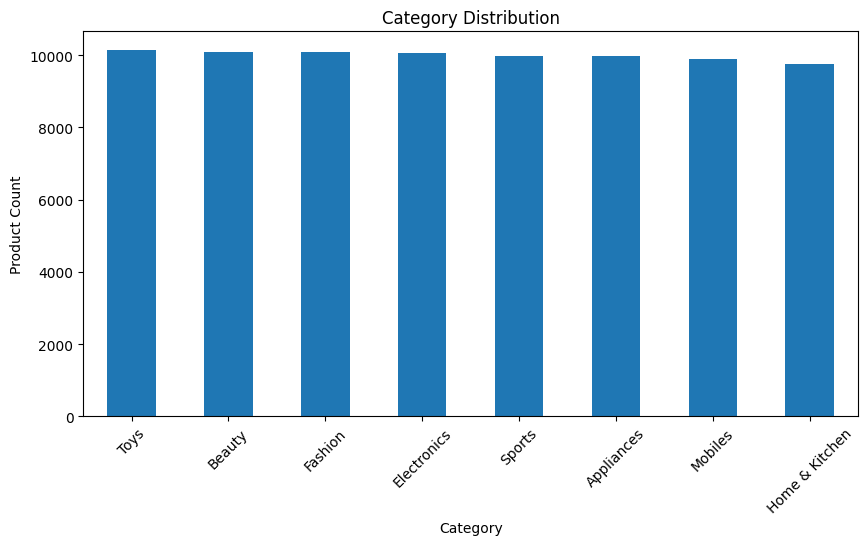

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
df["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Product Count")
plt.xticks(rotation=45)
plt.show()

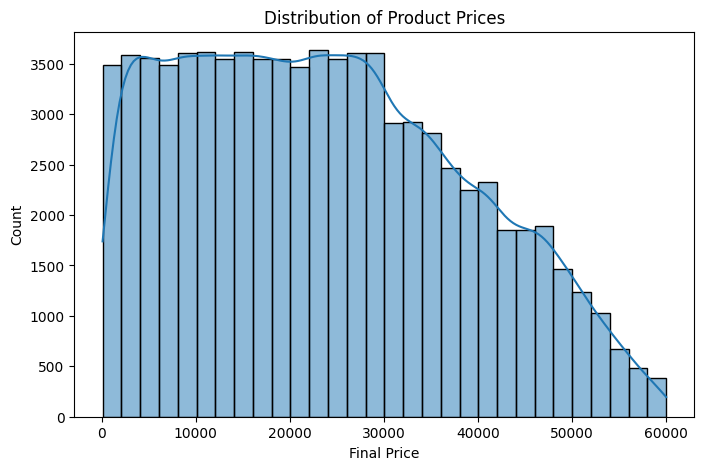

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["final_price"], bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Final Price")
plt.ylabel("Count")
plt.show()

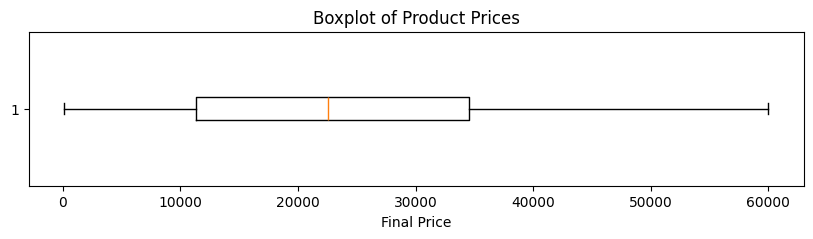

In [ ]:
plt.figure(figsize=(10,2))
plt.boxplot(df["final_price"], vert=False)
plt.title("Boxplot of Product Prices")
plt.xlabel("Final Price")
plt.show()

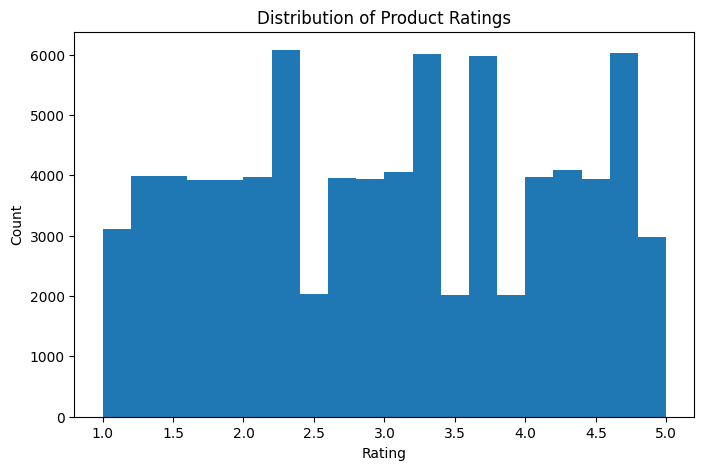

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["rating"], bins=20)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

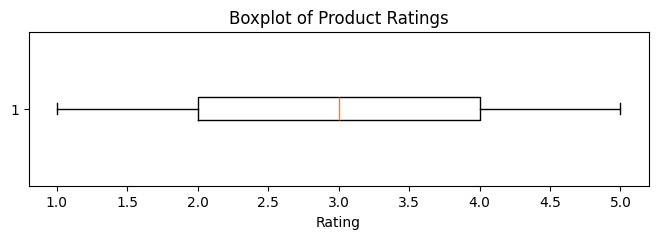

In [ ]:
plt.figure(figsize=(8,2))
plt.boxplot(df["rating"], vert=False)
plt.title("Boxplot of Product Ratings")
plt.xlabel("Rating")
plt.show()

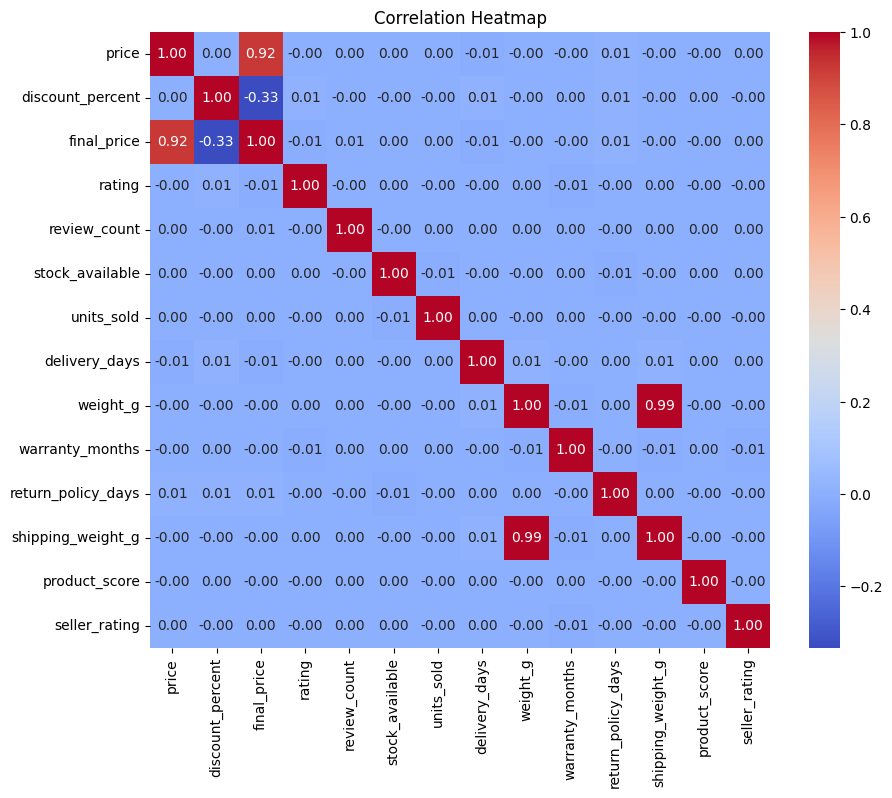

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

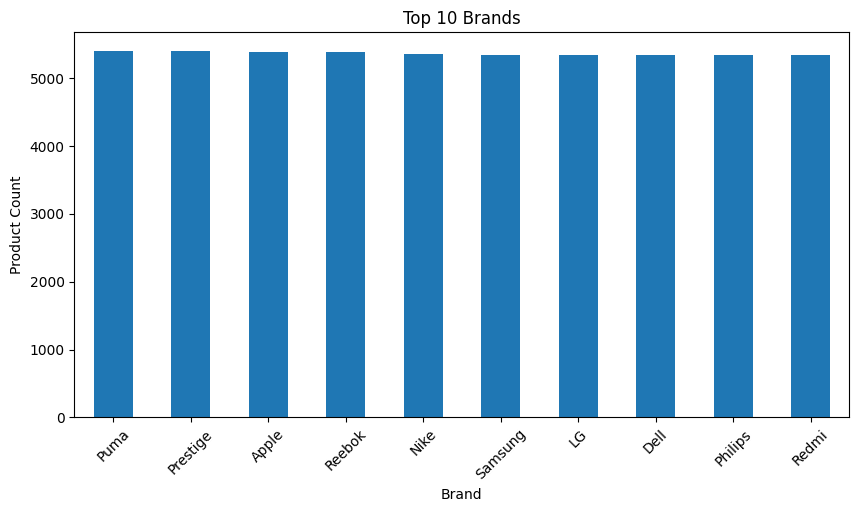

In [ ]:
plt.figure(figsize=(10,5))
df["brand"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Product Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["discount_amount"] = df["price"] - df["final_price"]

In [ ]:
latest_date = df["listing_date"].max()
df["product_age"] = (latest_date - df["listing_date"]).dt.days

In [ ]:
from sklearn.preprocessing import MinMaxScaler
popular = ["rating","review_count","units_sold","product_score","seller_rating"]
minmax = MinMaxScaler()
scaled = minmax.fit_transform(df[popular])

In [ ]:
df["popularity_score"] = (0.30 * scaled[:,0]+ 0.20 * scaled[:,1]+ 0.20 * scaled[:,2]+ 0.20 * scaled[:,3]+ 0.10 * scaled[:,4])

In [ ]:
features = ["category", "brand", "color", "size", "final_price", "discount_percent", "rating", "review_count", "units_sold", "product_score", "seller_rating", "product_age", "popularity_score"]
X = df[features].copy()

In [ ]:
X = pd.get_dummies(X,columns=["category", "brand", "color", "size"])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.neighbors import NearestNeighbors
def recommend(product_name, n=10):
    if product_name not in df["product_name"].values:
        return "Product not found"
    selected = df[df["product_name"] == product_name].iloc[0]
    filtered = df[df["category"] == selected["category"]]
    brand_filtered = filtered[
        filtered["brand"] == selected["brand"]
    ]
    if len(brand_filtered) >= 20:
        filtered = brand_filtered
    price = selected["final_price"]

    filtered = filtered[
        (filtered["final_price"] >= price * 0.8) &
        (filtered["final_price"] <= price * 1.2)
    ]
    if len(filtered) < 15:
        filtered = df[df["category"] == selected["category"]]
    rating = selected["rating"]

    filtered = filtered[
    (filtered["rating"] >= rating - 1) &
    (filtered["rating"] <= rating + 1)
     ]
    if len(filtered) < 15:
         filtered = brand_filtered
    idx = filtered.index
    X_filtered = X[idx]
    model = NearestNeighbors(
        metric="cosine",
        algorithm="brute",
        n_neighbors=min(n + 1, len(filtered))
    )
    model.fit(X_filtered)
    query_index = list(idx).index(selected.name)
    distances, indices = model.kneighbors(
        X_filtered[query_index].reshape(1, -1)
    )
    recommendations = filtered.iloc[indices[0][1:]]
    recommendations = recommendations.copy()
    recommendations["Similarity"] = (1 - distances[0][1:]).round(3)
    return recommendations[
        [
            "product_name",
            "category",
            "brand",
            "final_price",
            "rating",
            "Similarity"
        ]
    ].reset_index(drop=True)

In [ ]:
recommend(df["product_name"].iloc[0])

,product_name,category,brand,final_price,rating,Similarity
0,Adidas Model 401,Toys,Adidas,35777.44,1.9,0.890
1,Adidas Prime 800,Toys,Adidas,27393.09,2.1,0.815
2,Adidas Prime 703,Toys,Adidas,29880.83,1.8,0.808
3,Adidas Edition 865,Toys,Adidas,35095.95,2.9,0.787
4,Adidas Series 666,Toys,Adidas,25404.42,2.6,0.755
5,Adidas Series 807,Toys,Adidas,30094.14,2.6,0.731
6,Adidas Prime 500,Toys,Adidas,32370.26,1.1,0.728
7,Adidas Prime 558,Toys,Adidas,25967.53,1.5,0.673
8,Adidas Series 270,Toys,Adidas,27130.49,2.6,0.672
9,Adidas Series 566,Toys,Adidas,27181.60,1.7,0.668


In [ ]:
import joblib
joblib.dump(X, "X_scaled.pkl")
joblib.dump(df, "products.pkl")

['products.pkl']